# Generate data from the multiple regression model
- We will be creating a dataset from the multiple regression model using the function `make_regression` from the library ***sklearn.datasets***.
- Assign to the number of samples, features, as well as the standard deviation of the noise and bias values.
- Hyperparameters for genereating data points:
    - `n_train`: integer. The number of the training samples.
    - `n_val`: integer. The number of the validation samples.
    - `n_test`: integer. The number of the test samples.
    - **n_samples**: integer. The number of whole dataset combined. **n_samples** = `n_train` + `n_val` + `n_test`.
    - `n_features`: integer. The number of features of the multiple regression model which we are generate datapoints from.
    - `sd_noise`: tuple. The standard deviation of the gaussian noise applied to the output.
    - `bias_val`: tuple. The bias term in the underlying linear model.
    - `random_state_val`: integer. RNG seed number used in dataset creation.
- A typical split ratio of the datasets might be $\text{Training} : \text{Validation} : \text{Test} = 70 : 15 : 15$ or $60 : 20 : 20$.
- Also, the generated data has been scaled: X_data ranges from $-\pi$ to $\pi$, suitable for applying to rotation angles, and Y_data spans from $-1$ to $1$, applicable for representing $\langle Z \rangle$, respectively.

### Create output folder

In [1]:
import os

dataset_dir = 'dataset_trig_w_error/'    # dataset_mr_wo_error, dataset_mr_w_error
dataset_EDA_dir = dataset_dir+'EDA_result/'

# Create the folder if it doesn't exist
if not os.path.exists(dataset_dir):
    os.makedirs(dataset_dir)

if not os.path.exists(dataset_EDA_dir):
    os.makedirs(dataset_EDA_dir)

# Set save folder directory
print('dataset_dir:', dataset_dir)
print('dataset_EDA_dir:', dataset_EDA_dir)

dataset_dir: dataset_trig_w_error/
dataset_EDA_dir: dataset_trig_w_error/EDA_result/


### Generate dataset

In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_regression
from sklearn.preprocessing import MinMaxScaler

In [3]:
def n_sample_calc(number, r_train, r_val, r_test):
    n_train = round(number * r_train)
    n_val = round(number * r_val)
    n_test = round(number * r_test)
    n_samples = n_train + n_val + n_test
    print('---Calculation of the number of samples of each dataset---')
    print('n_train:', n_train)
    print('n_train:', n_val)
    print('n_train:', n_test)
    print('n_samples:', n_samples)

In [4]:
# n_train, n_val, n_test = ratio_func(200, 0.6, 0.2, 0.2)
n_sample_calc(140, 0.7, 0.15, 0.15)

---Calculation of the number of samples of each dataset---
n_train: 98
n_train: 21
n_train: 21
n_samples: 140


In [5]:
# Assign the number of samples and features
n_train = 100
n_val = 20
n_test = 20
n_samples = n_train + n_val + n_test

print('---Assigned number of samples for each dataset---')
print('n_train:', n_train)
print('n_val:', n_val)
print('n_test:', n_test)
print('n_samples:', n_samples, '\n')

n_features = 4
n_informative = 4

if dataset_dir == 'dataset_trig_wo_error/':
    noise_sd = 0.0
    bias_val = 0.0
elif dataset_dir == 'dataset_trig_w_error/':
    noise_sd = 0.001
    bias_val = 0.0

random_state_val = 42

print('---Parameters of the function `make_regression`---')
print('n_features:', n_features)
print('noise_sd:', noise_sd)
print('bias_val:', bias_val)
print('random_state_val:', random_state_val)

---Assigned number of samples for each dataset---
n_train: 100
n_val: 20
n_test: 20
n_samples: 140 

---Parameters of the function `make_regression`---
n_features: 4
noise_sd: 0.001
bias_val: 0.0
random_state_val: 42


In [6]:
# Generate 4 independent variables uniformly in the range [0, 2π]
x2 = np.random.uniform(0, 2*np.pi, n_samples)
x1 = np.random.uniform(0, 2*np.pi, n_samples)
x3 = np.random.uniform(0, 2*np.pi, n_samples)
x4 = np.random.uniform(0, 2*np.pi, n_samples)

# Define the dependent variable using trigonometric functions
noise = np.random.normal(loc=0, scale=noise_sd, size=n_samples)
y = np.sin(x1) + 0.1 * np.cos(x2) - 0.33 * np.sin(x3) + 0.2 * np.cos(x4) + noise

# Normalize y to range [-1, 1]
y = (y - np.min(y)) / (np.max(y) - np.min(y)) * 2 - 1

# Create DataFrame
data = pd.DataFrame({
    'feature1': x1,
    'feature2': x2,
    'feature3': x3,
    'feature4': x4,
    'target': y
})

print('Data head:\n', data.head(), '\n')
print('Data description:\n', data.describe(), '\n')

Data head:
    feature1  feature2  feature3  feature4    target
0  5.902968  1.120490  4.865955  0.452802  0.074606
1  5.018389  3.693805  2.730447  5.935916 -0.734916
2  5.649760  1.538241  4.215835  0.960344 -0.177296
3  5.686272  5.917859  2.887154  1.234117 -0.386813
4  0.412027  1.885315  1.946404  0.678241  0.102487 

Data description:
          feature1    feature2    feature3    feature4      target
count  140.000000  140.000000  140.000000  140.000000  140.000000
mean     3.313524    2.993850    3.163331    3.044171   -0.138368
std      1.792688    1.808556    1.863423    1.843936    0.542150
min      0.004021    0.010559    0.016687    0.011844   -1.000000
25%      1.870056    1.442309    1.712253    1.351256   -0.594791
50%      3.480051    3.154950    3.031716    3.112471   -0.157998
75%      4.860424    4.701322    4.854384    4.597934    0.305106
max      6.027075    6.161782    6.281134    6.264229    1.000000 



# Split the dataset into training, validation, and test sets.
- We will be splitting the data into training, validation, and test datasets, with specified numbers of data points for each.

In [7]:
from sklearn.model_selection import train_test_split

# Split data into training + validation and test sets
data_train_val, data_test = train_test_split(data, test_size=n_test, random_state=random_state_val)

# Now split the training + validation set into separate training and validation sets
data_train, data_val = train_test_split(data_train_val, test_size=n_val, random_state=random_state_val)

print('---Shape of each datasets---')
print("Training set shape:", data_train.shape)
print("Validation set shape:", data_val.shape)
print("Test set shape:", data_test.shape)

---Shape of each datasets---
Training set shape: (100, 5)
Validation set shape: (20, 5)
Test set shape: (20, 5)


# Exploratory Data Analysis (EDA) on the generated dataset

## Scatter plot of the dataset

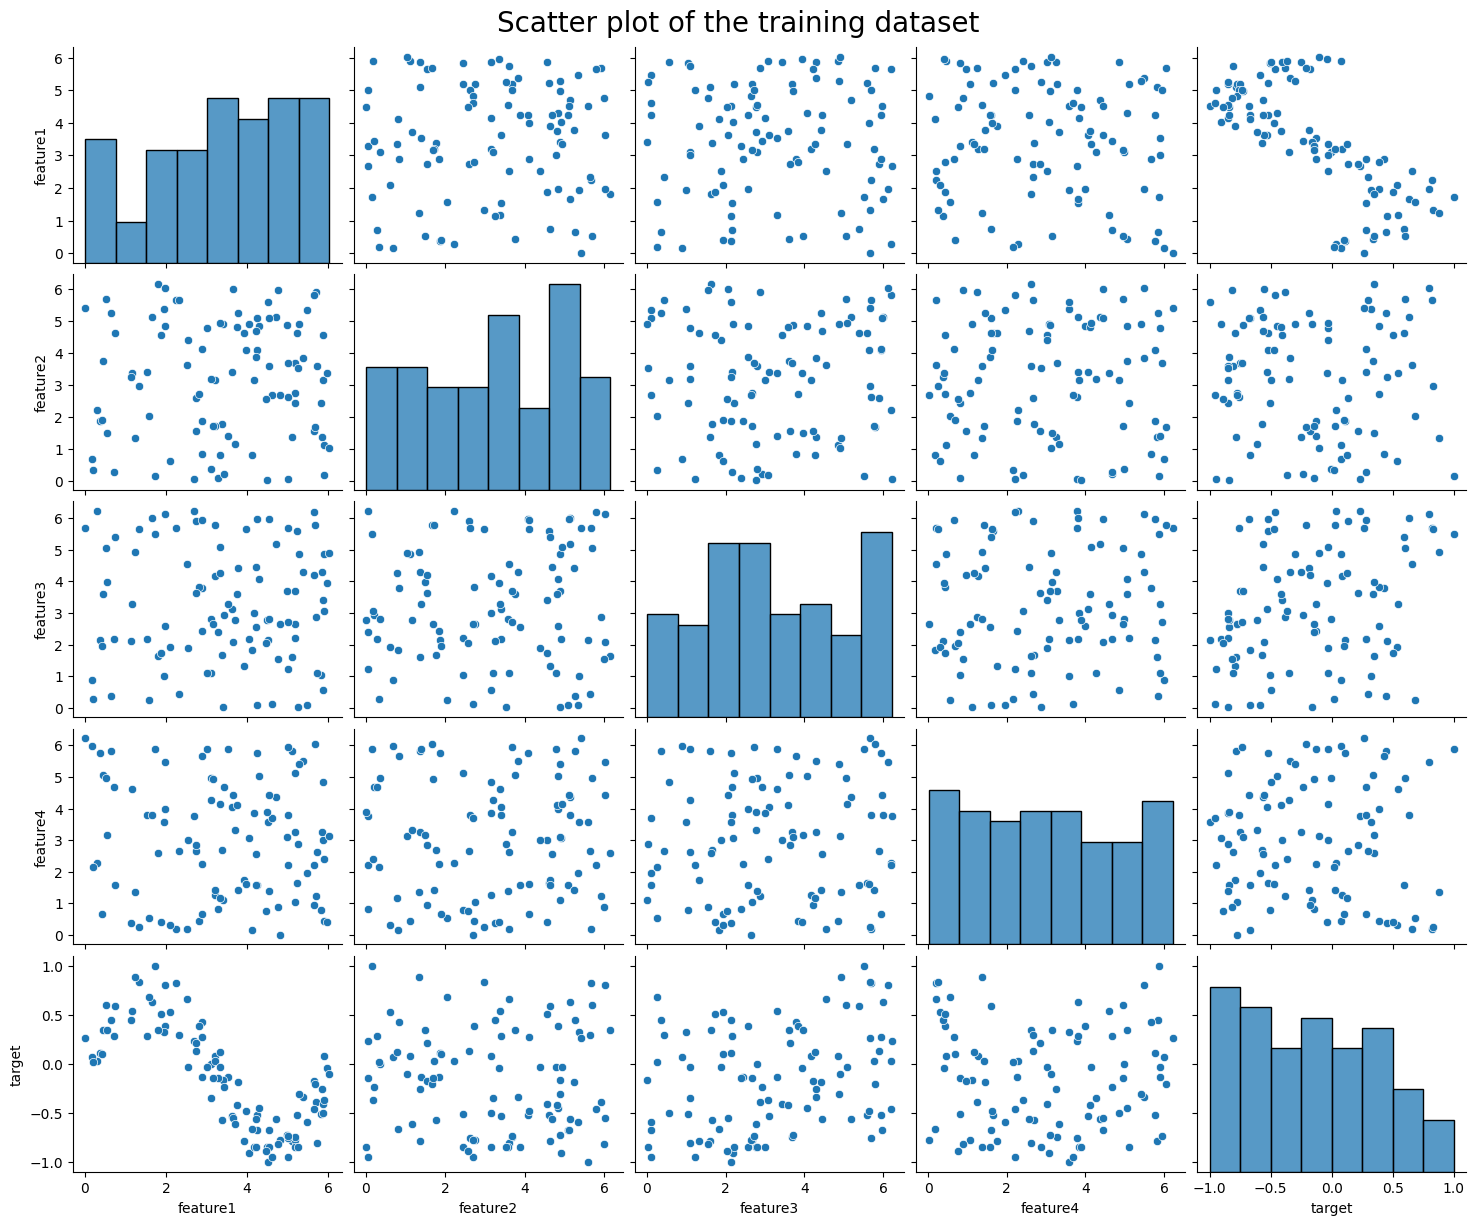

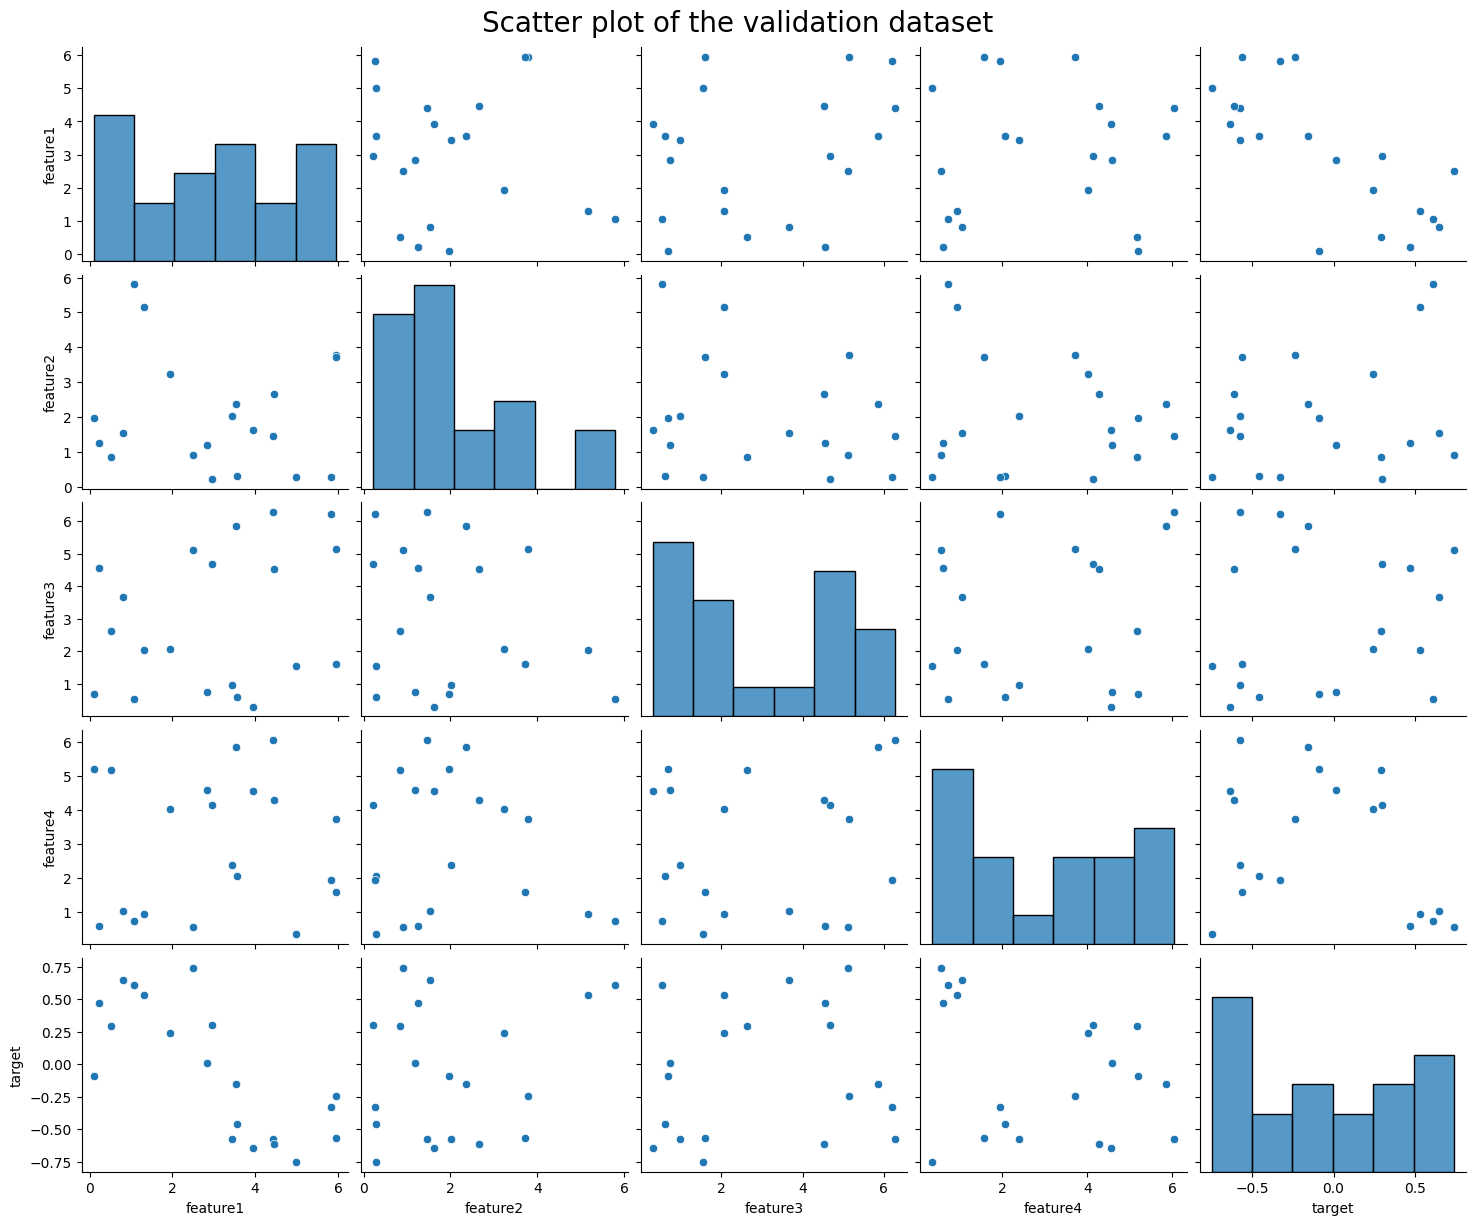

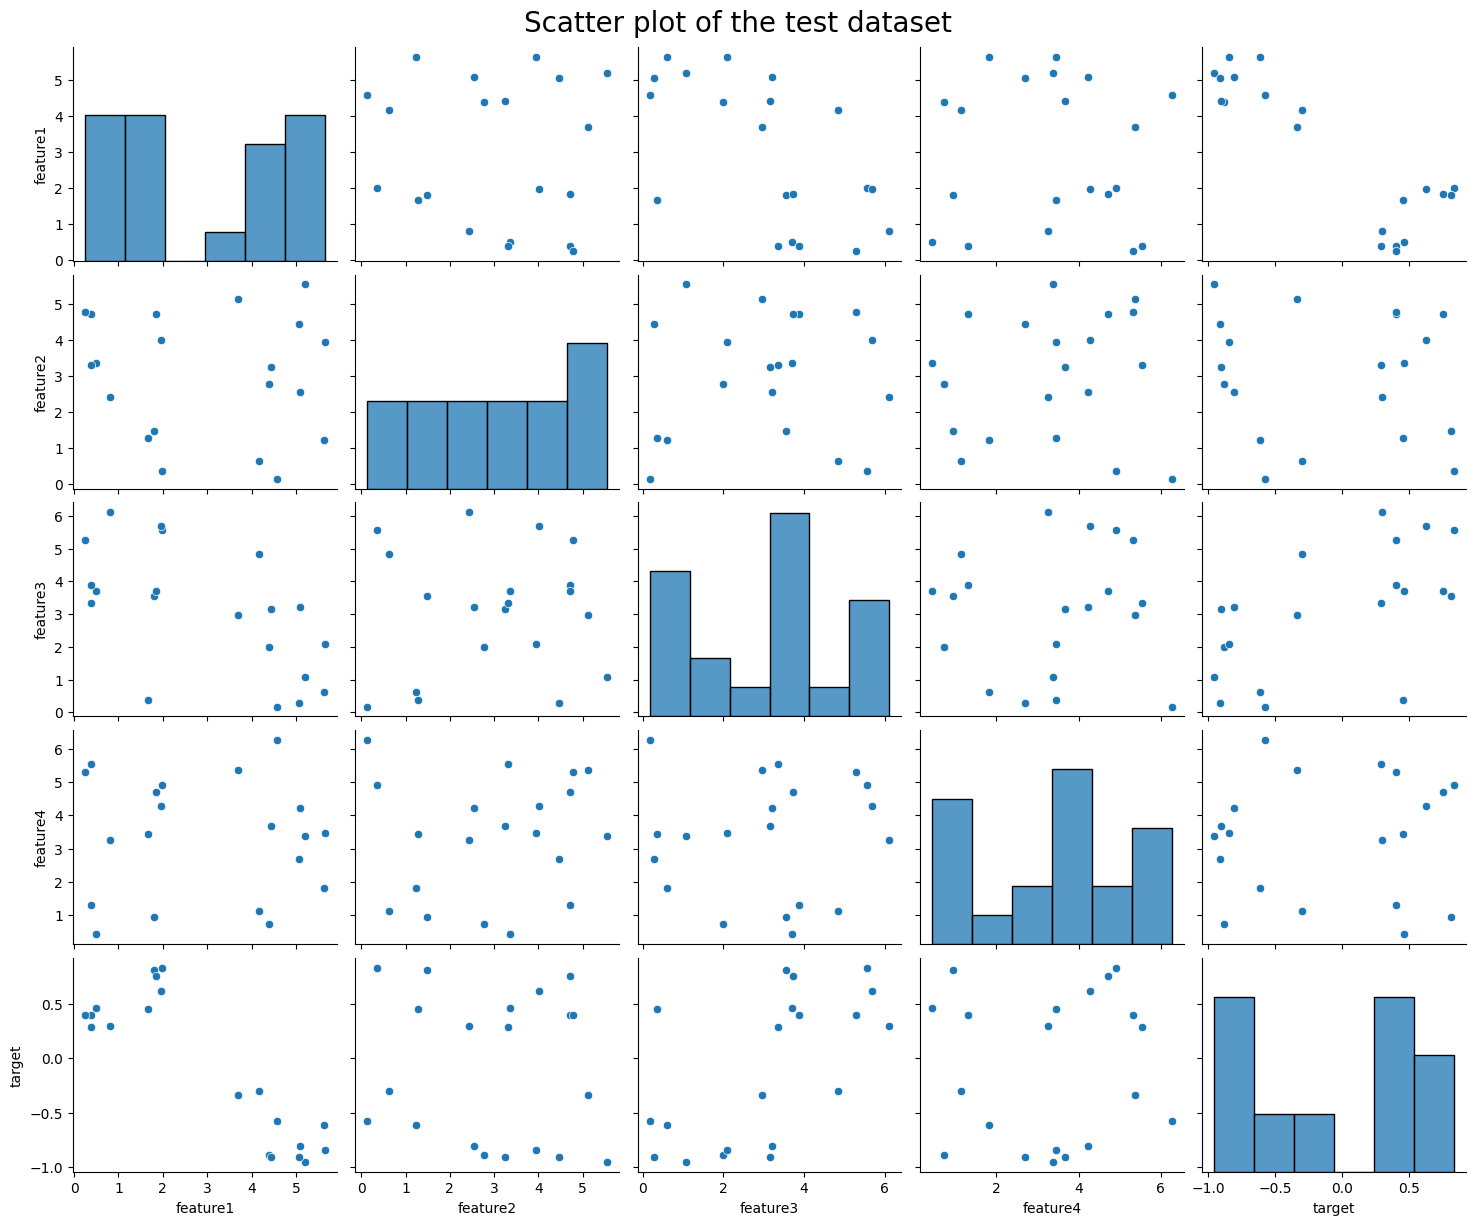

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting the pairwise scatter plot
scatter_plot = sns.pairplot(data_train, height=2.5, aspect=1.2)
plt.subplots_adjust(top=0.95) # Adjust the top margin of the plot
plt.suptitle('Scatter plot of the training dataset', fontsize=20)
plt.savefig(dataset_EDA_dir + 'scatter_plot_training_dataset.png')
plt.show()

scatter_plot_val = sns.pairplot(data_val, height=2.5, aspect=1.2)
plt.subplots_adjust(top=0.95)  # Adjust the top margin of the plot
plt.suptitle('Scatter plot of the validation dataset', fontsize=20)
plt.savefig(dataset_EDA_dir + 'scatter_plot_validation_dataset.png')
plt.show()

scatter_plot_test = sns.pairplot(data_test, height=2.5, aspect=1.2)
plt.subplots_adjust(top=0.95)  # Adjust the top margin of the plot
plt.suptitle('Scatter plot of the test dataset', fontsize=20)
plt.savefig(dataset_EDA_dir + 'scatter_plot_test_dataset.png')
plt.show()

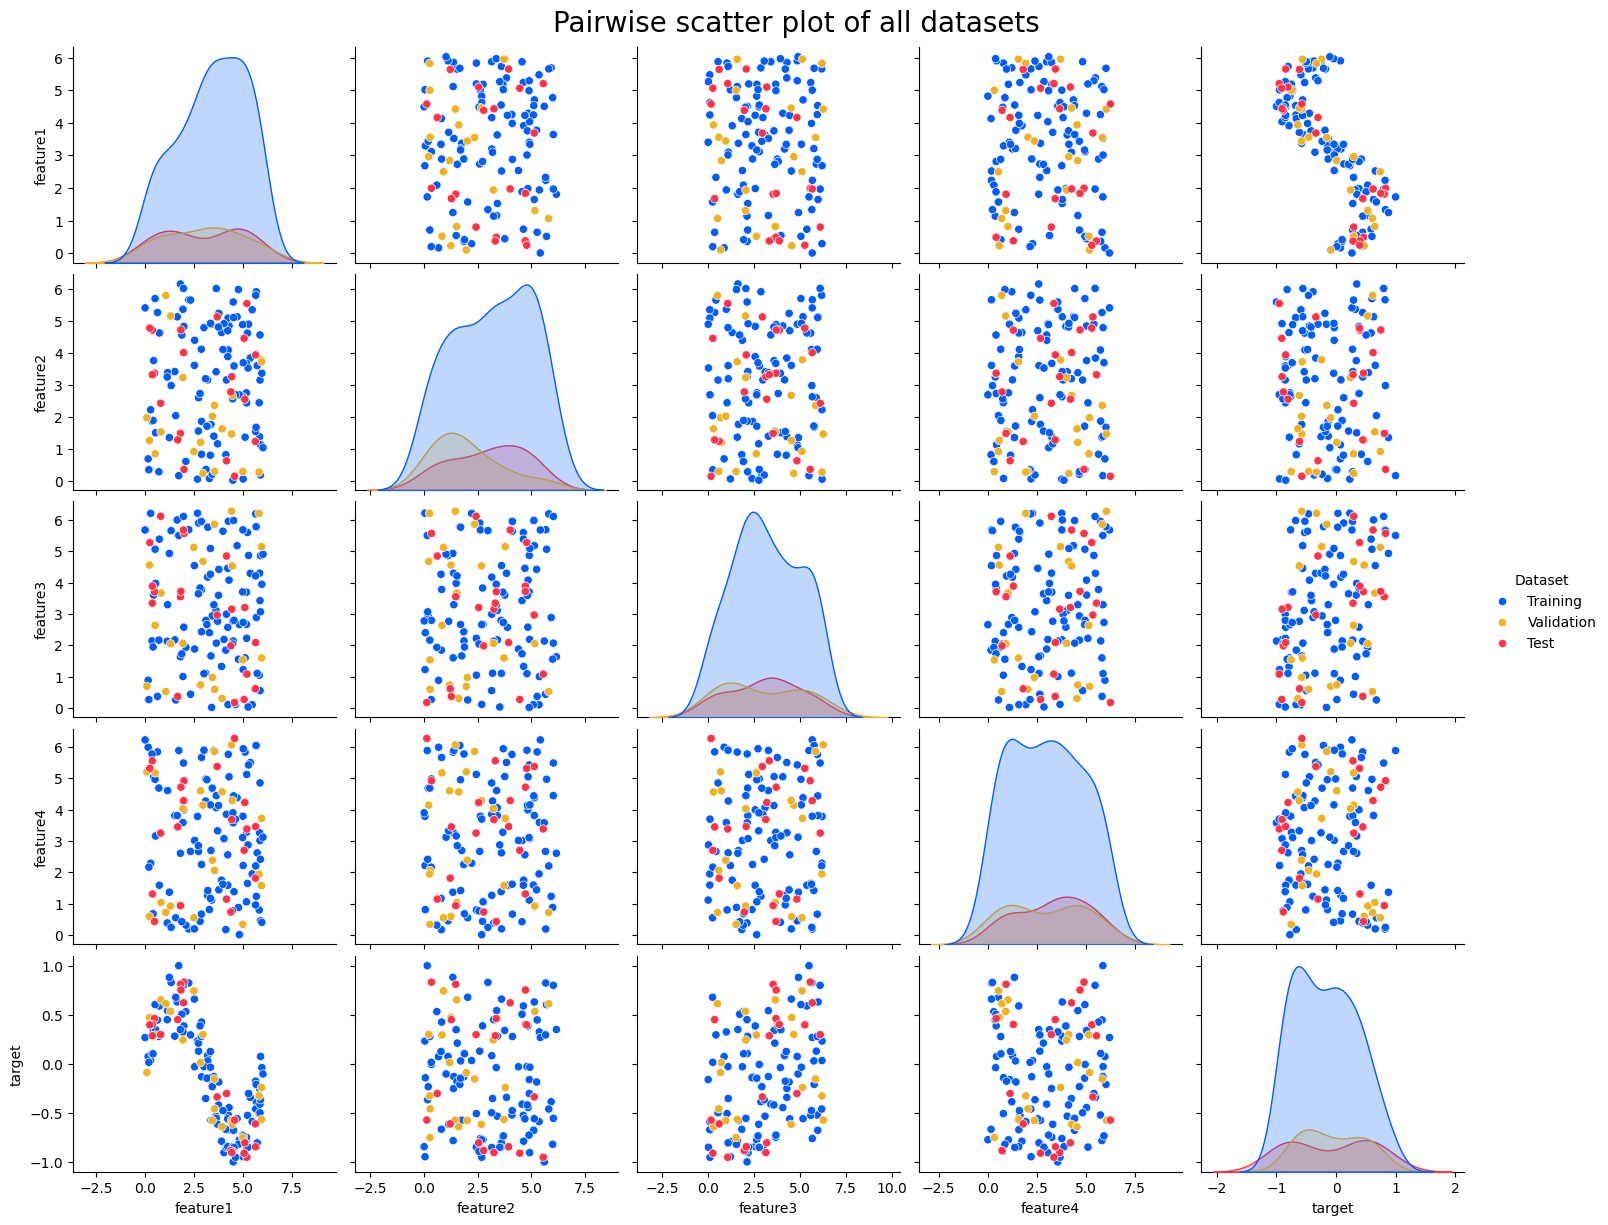

In [9]:
import pandas as pd

# Concatenate the dataframes
combined_data = pd.concat([data_train, data_val, data_test], ignore_index=True)

# Create a list with the dataset labels according to the number of datapoints
dataset_labels = (['Training'] * n_train) + (['Validation'] * n_val) + (['Test'] * n_test)

# Assign this list as a new column in the combined dataframe
combined_data['Dataset'] = dataset_labels

# Custom palette for color vision deficiencies
custom_palette = {'Training': '#005dfb',
                  'Validation': '#f0b123',
                  'Test': '#ff3448'}

# Plot using seaborn's pairplot with the 'hue' parameter
scatter_plot_combined = sns.pairplot(combined_data, hue='Dataset', height=2.5, aspect=1.2, palette=custom_palette)
plt.suptitle('Pairwise scatter plot of all datasets', fontsize=20)
plt.subplots_adjust(top=0.95)

# Save the plot
plt.savefig(dataset_EDA_dir + 'scatter_plot_combined_datasets.png')
plt.savefig(dataset_EDA_dir + 'scatter_plot_combined_datasets.pdf')
plt.show()

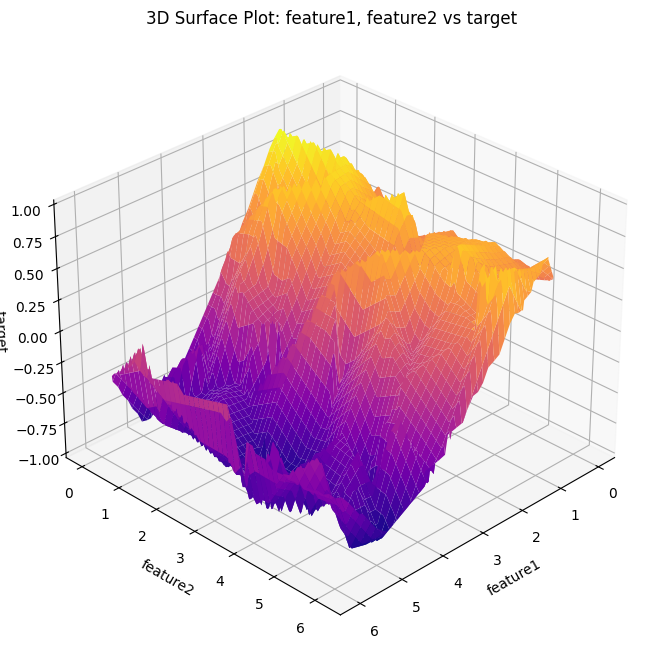

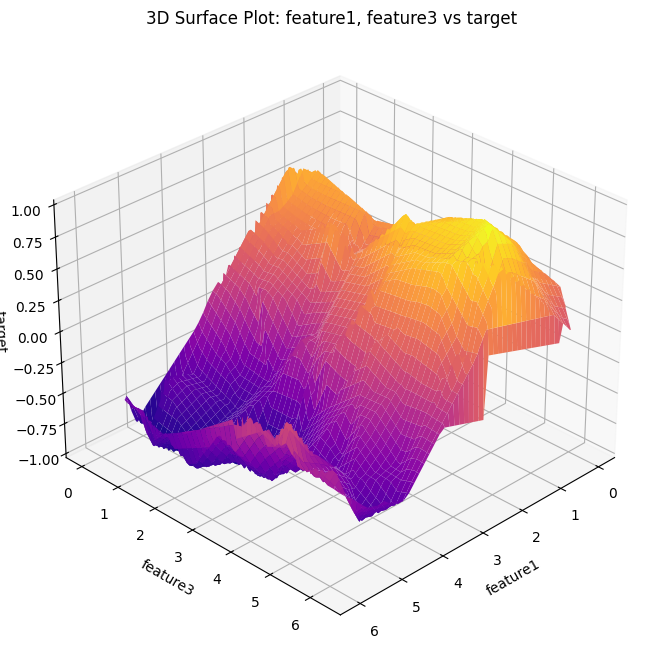

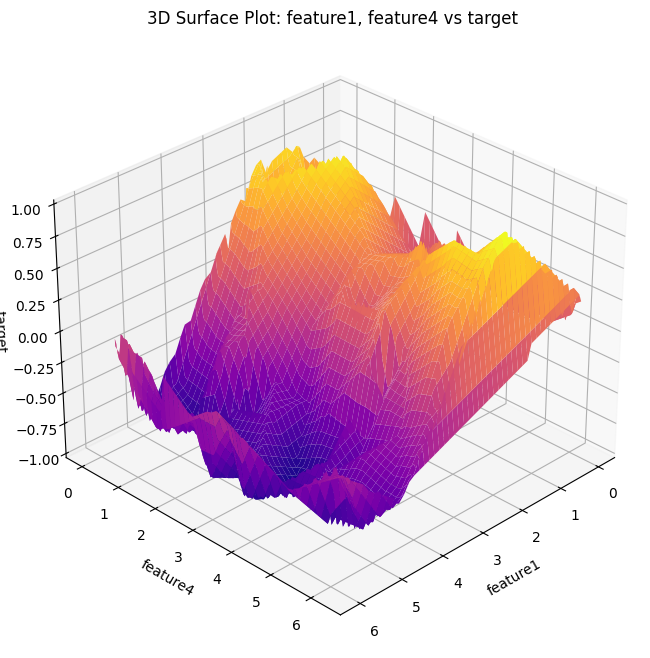

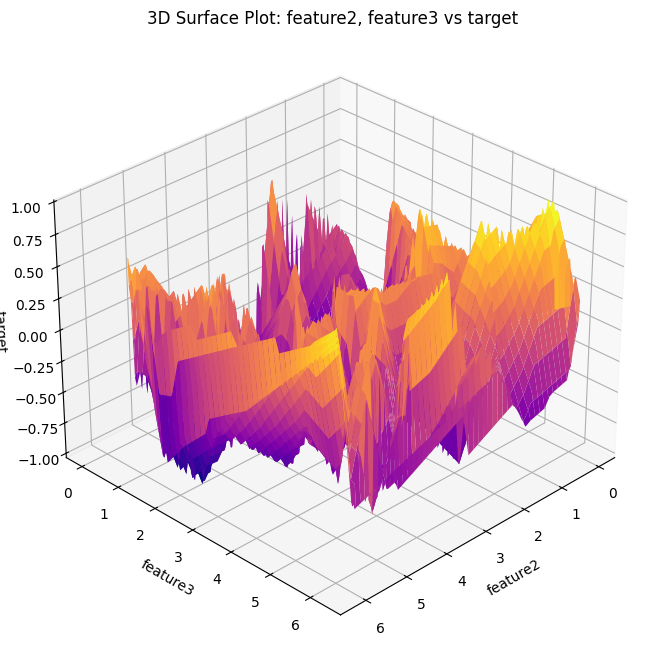

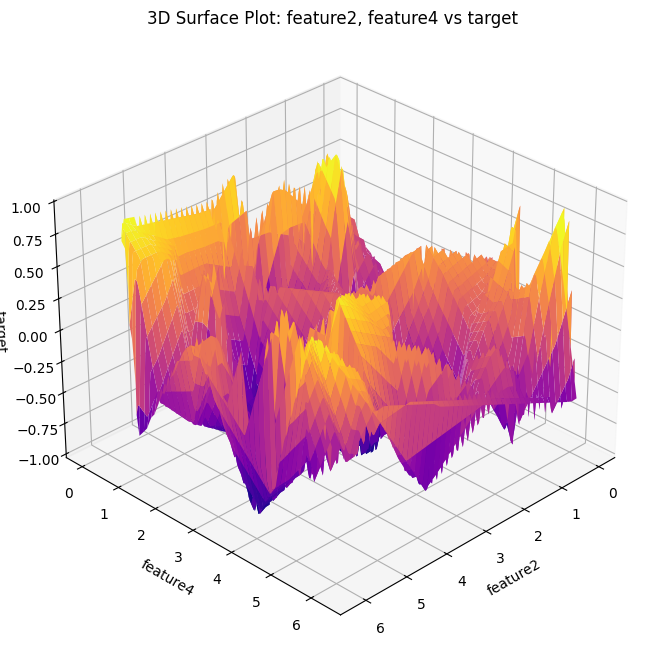

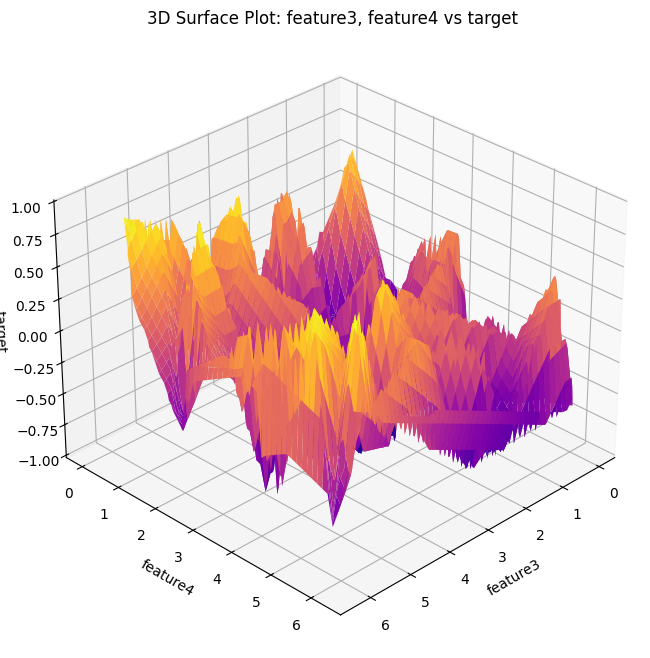

In [10]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from itertools import combinations
from scipy.interpolate import griddata

# Assuming your dataset is stored in a DataFrame 'data'
# 'feature1', 'feature2', 'feature3', 'feature4' are the column names for your features
# 'target' is the column name for your target variable

# Extract the feature names and the target column
features = ['feature1', 'feature2', 'feature3', 'feature4']
target = 'target'

# Define a function to create a 3D surface plot for a given pair of features and the target
def plot_3d_surface(data, feature_x, feature_y, target, figsize=(10, 7), elev=30, azim=120):
    x = data[feature_x]
    y = data[feature_y]
    z = data[target]

    # Create a grid of x and y values
    xi = np.linspace(x.min(), x.max(), 200)
    yi = np.linspace(y.min(), y.max(), 200)
    xi, yi = np.meshgrid(xi, yi)

    # Interpolate z values on the grid
    zi = griddata((x, y), z, (xi, yi), method='linear') # 'linear', 'cubic', 'nearest'

    # Create the plot with specified size
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')

    # Plot the surface
    surf = ax.plot_surface(xi, yi, zi, cmap='plasma') # 'viridis', 'coolwarm', 'plasma'

    # Set the rotation angle
    ax.view_init(elev=elev, azim=azim)

    # Add labels and title
    ax.set_xlabel(feature_x)
    ax.set_ylabel(feature_y)
    ax.set_zlabel(target)
    ax.set_title(f'3D Surface Plot: {feature_x}, {feature_y} vs {target}')

    # Show the plot
    plt.show()

# Generate 3D surface plots for all combinations of pairs of features
# You can specify custom figsize, elevation, and azimuth values as needed
for feature_x, feature_y in combinations(features, 2):
    plot_3d_surface(data, feature_x, feature_y, target, figsize=(12, 8), elev=30, azim=45)


In [11]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from itertools import combinations
from scipy.interpolate import griddata

# Assuming your dataset is stored in a DataFrame 'data'
# 'feature1', 'feature2', 'feature3', 'feature4' are the column names for your features
# 'target' is the column name for your target variable

# Extract the feature names and the target column
features = ['feature1', 'feature2', 'feature3', 'feature4']
target = 'target'

def plot_3d_surface(ax, data, feature_x, feature_y, target, elev=30, azim=45):
    x = data[feature_x]
    y = data[feature_y]
    z = data[target]

    # Create a grid of x and y values
    xi = np.linspace(x.min(), x.max(), 100)
    yi = np.linspace(y.min(), y.max(), 100)
    xi, yi = np.meshgrid(xi, yi)

    # Interpolate z values on the grid
    zi = griddata((x, y), z, (xi, yi), method='linear')

    # Plot the surface
    surf = ax.plot_surface(xi, yi, zi, cmap='plasma') # 'viridis', 'coolwarm', 'plasma'
    
    # Set the rotation angle
    ax.view_init(elev=elev, azim=azim)

    # Add labels
    ax.set_xlabel(feature_x)
    ax.set_ylabel(feature_y)
    ax.set_zlabel(target)
    ax.set_title(f'{feature_x}, {feature_y} vs {target}')

def create_3d_surface_grid(data, features, target, save_plot=False, filename=dataset_EDA_dir+'3d_surface_grid_dataset.png'):
    # Create a 2x3 grid of 3D surface plots
    fig = plt.figure(figsize=(20, 12))

    for i, (feature_x, feature_y) in enumerate(combinations(features, 2)):
        ax = fig.add_subplot(2, 3, i+1, projection='3d')
        plot_3d_surface(ax, data, feature_x, feature_y, target)
        ax.view_init(elev=30, azim=45)

    plt.tight_layout()
    
    if save_plot:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"Plot saved as {filename}")
    
    plt.show()

Plot saved as dataset_trig_w_error/EDA_result/3d_surface_grid_dataset.png


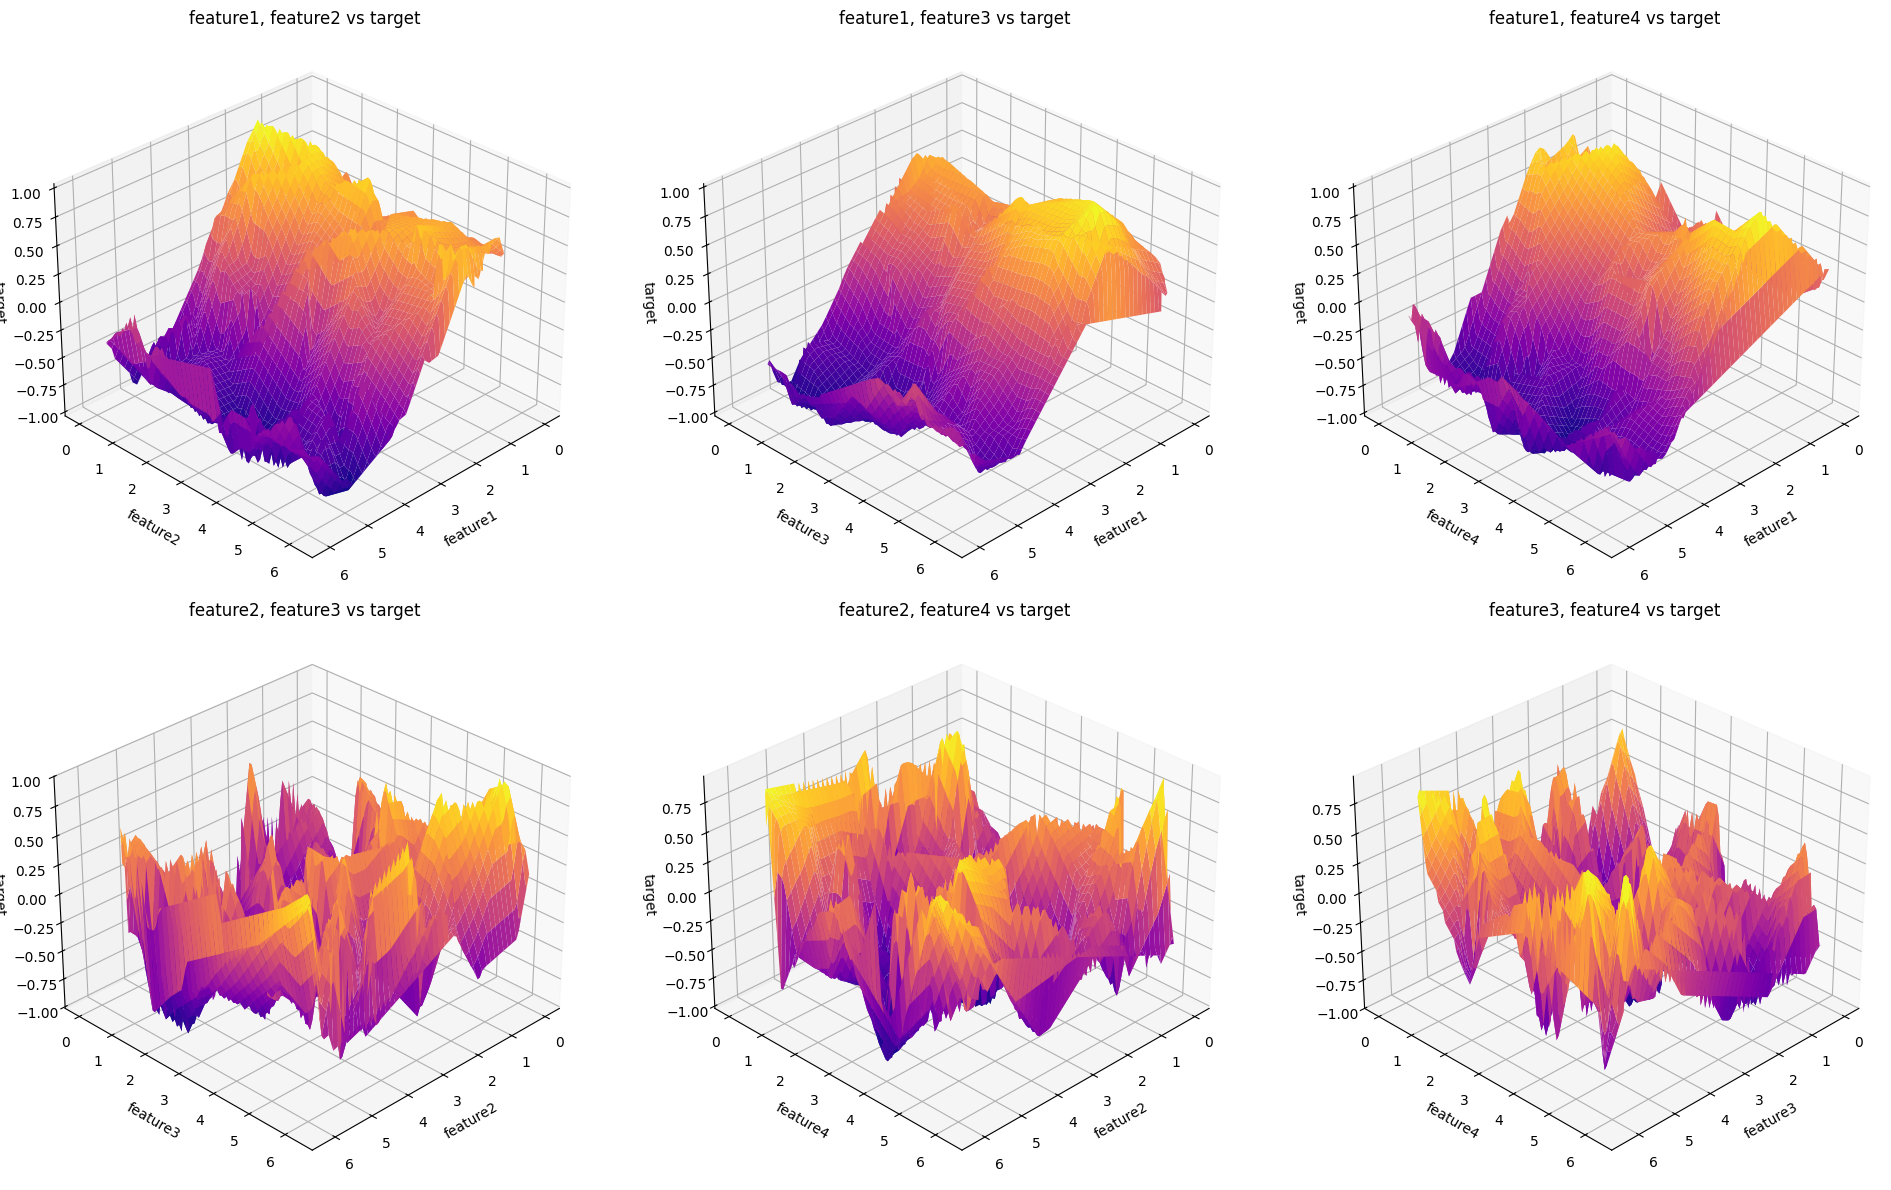

In [12]:
create_3d_surface_grid(data, features, target, save_plot=True)

## Descriptive statistics of the dataset

In [13]:
# Descriptive statistcs of each features of the DataFrame
data_train_stats = data_train.describe()
print(data_train_stats, '\n')

data_val_stats = data_val.describe()
print(data_val_stats, '\n')

data_test_stats = data_test.describe()
print(data_test_stats)

         feature1    feature2    feature3    feature4      target
count  100.000000  100.000000  100.000000  100.000000  100.000000
mean     3.440962    3.184921    3.214489    2.995417   -0.164124
std      1.728636    1.822597    1.818695    1.845053    0.524014
min      0.004021    0.010559    0.016687    0.011844   -1.000000
25%      2.061013    1.641029    1.921802    1.377661   -0.595854
50%      3.573208    3.373183    2.966694    3.012974   -0.169181
75%      4.989645    4.837266    4.866995    4.482851    0.278231
max      6.027075    6.161782    6.218021    6.218438    1.000000 

        feature1   feature2   feature3   feature4     target
count  20.000000  20.000000  20.000000  20.000000  20.000000
mean    3.017435   2.028395   2.989282   2.986574  -0.056914
std     1.923226   1.608038   2.130975   1.962154   0.501541
min     0.097455   0.221857   0.302517   0.341794  -0.751850
25%     1.245558   0.890635   0.915518   1.009706  -0.568181
50%     3.200872   1.573989   2.351846

In [14]:
# Add a column to indicate the dataset
data_train_stats['Dataset'] = 'Training'
data_val_stats['Dataset'] = 'Validation'
data_test_stats['Dataset'] = 'Test'

# Concatenate the descriptive statistics into a single DataFrame
all_stats = pd.concat([data_train_stats, data_val_stats, data_test_stats], axis=0)

# Reset the index if you want to make it a column in the CSV for clarity
all_stats.reset_index(inplace=True)

# Save the concatenated DataFrame to CSV
all_stats.to_csv(dataset_dir + 'all_datasets_descriptive_stats.csv', index=False)

## Boxplot of the dataset

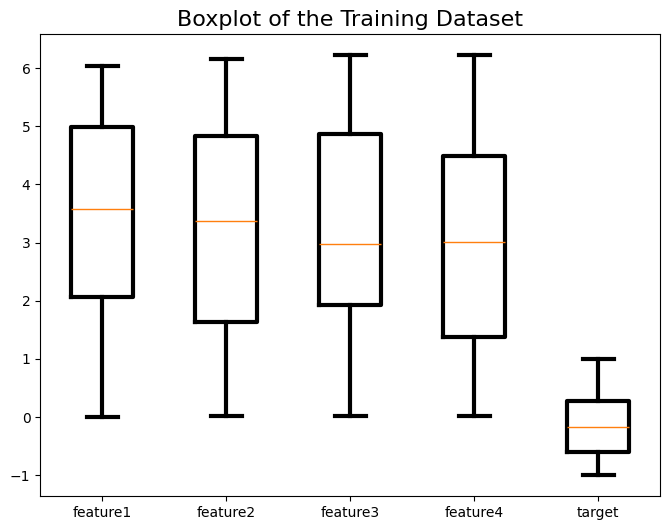

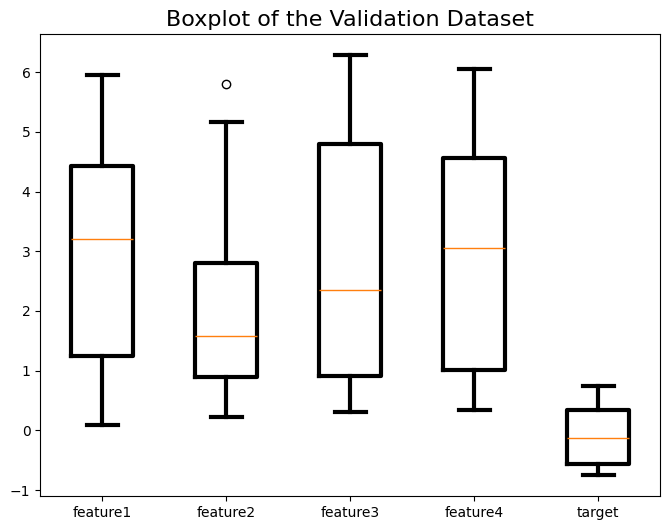

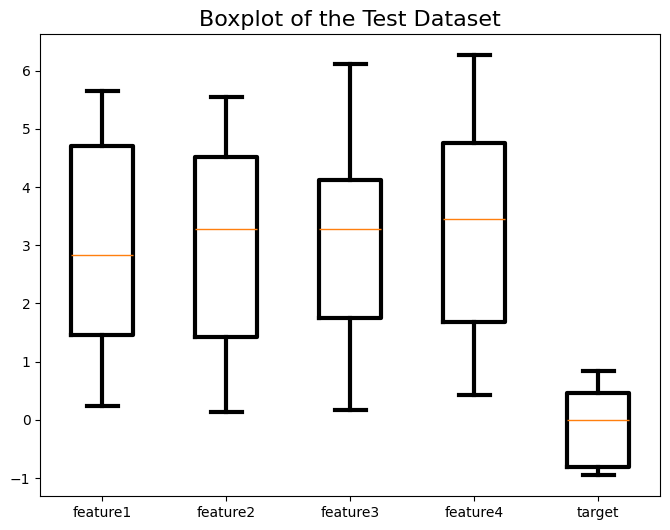

In [15]:
import matplotlib.pyplot as plt

# Common boxplot settings
boxprops = dict(linestyle='-', linewidth=3, color='k')
whiskerprops = dict(linestyle='-', linewidth=3, color='k')
capprops = dict(linestyle='-', linewidth=3, color='k')

# Plot for Training Dataset
fig, ax = plt.subplots(figsize=(8, 6))
ax.boxplot(data_train, boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops)
ax.set_title('Boxplot of the Training Dataset', fontsize=16)
ax.set_xticklabels(data_train.columns, fontsize=10)
plt.savefig(dataset_EDA_dir + 'boxplot_training_dataset.png')
plt.show()

# Plot for Validation Dataset
fig, ax = plt.subplots(figsize=(8, 6))
ax.boxplot(data_val, boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops)
ax.set_title('Boxplot of the Validation Dataset', fontsize=16)
ax.set_xticklabels(data_val.columns, fontsize=10)
plt.savefig(dataset_EDA_dir + 'boxplot_validation_dataset.png')
plt.show()

# Plot for Test Dataset
fig, ax = plt.subplots(figsize=(8, 6))
ax.boxplot(data_test, boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops)
ax.set_title('Boxplot of the Test Dataset', fontsize=16)
ax.set_xticklabels(data_test.columns, fontsize=10)
plt.savefig(dataset_EDA_dir + 'boxplot_test_dataset.png')
plt.show()


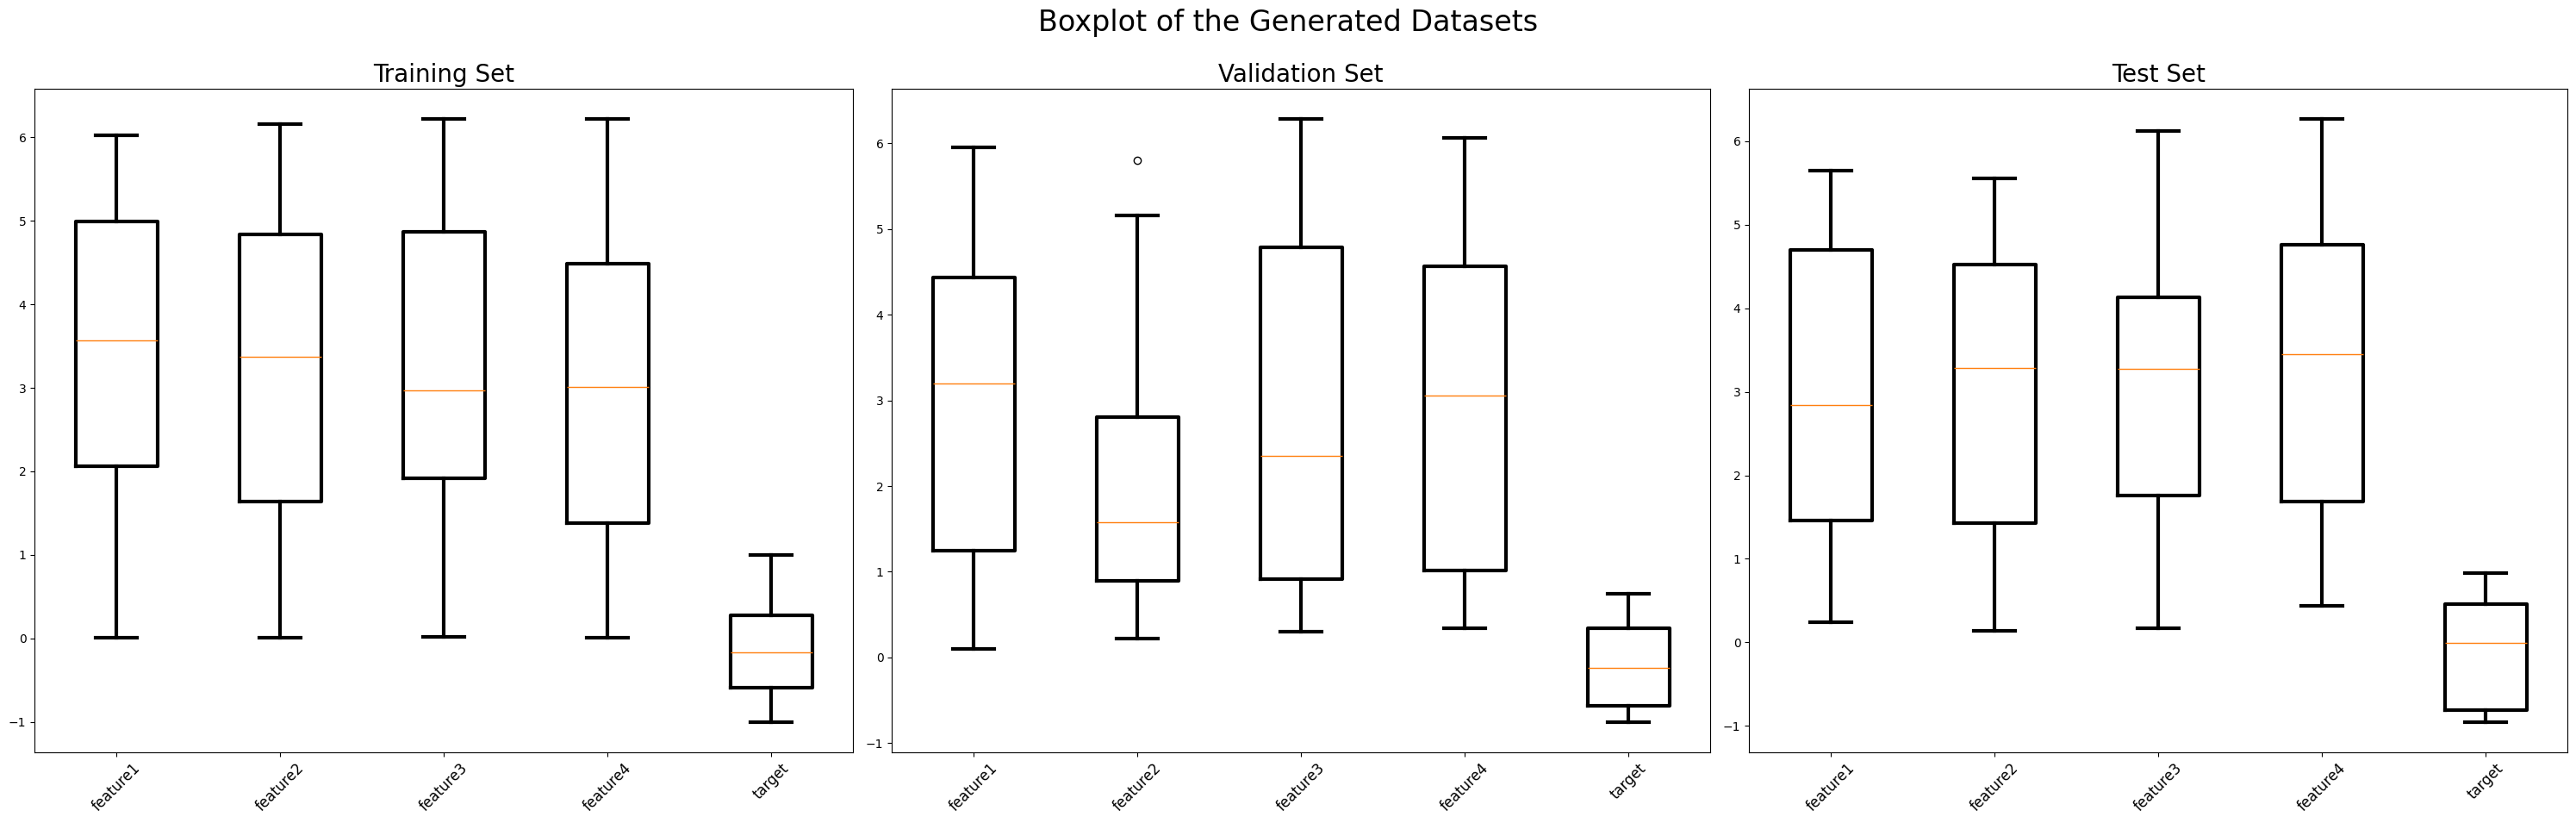

In [16]:
import matplotlib.pyplot as plt

# Define boxplot properties
boxprops = dict(linestyle='-', linewidth=3, color='k')
whiskerprops = dict(linestyle='-', linewidth=3, color='k')
capprops = dict(linestyle='-', linewidth=3, color='k')

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(30, 10))  # Adjust figsize to suit your needs

# Plot boxplot for each dataset
datasets = [data_train, data_val, data_test]
titles = ['Training Set', 'Validation Set', 'Test Set']

for ax, dataset, title in zip(axes, datasets, titles):
    ax.boxplot(dataset, boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops)
    ax.set_title(title, fontsize=20)
    ax.set_xticklabels(dataset.columns, fontsize=12, rotation=45)  # Rotate labels for better legibility

fig.suptitle('Boxplot of the Generated Datasets', fontsize=24)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])  # Adjust the rect parameters as needed for the title and labels
plt.savefig(dataset_EDA_dir + 'boxplot_combined_datasets.png')
plt.savefig(dataset_EDA_dir + 'boxplot_combined_datasets.pdf')
plt.show()


## Correlation plot of the dataset

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define a function to create and save the heatmap
def create_heatmap(data, title, filename):
    correlation_matrix = data.corr()
    plt.figure(figsize=(10, 6))
    sns.heatmap(correlation_matrix,
                vmin=-1, vmax=1, annot=True, annot_kws={"size": 10},
                cmap="coolwarm", fmt=".4f", square=True)
    plt.title(title, fontsize=24)
    plt.tick_params(axis='x', labelsize=10)
    plt.tick_params(axis='y', labelsize=10)
    plt.savefig(filename)
    plt.show()

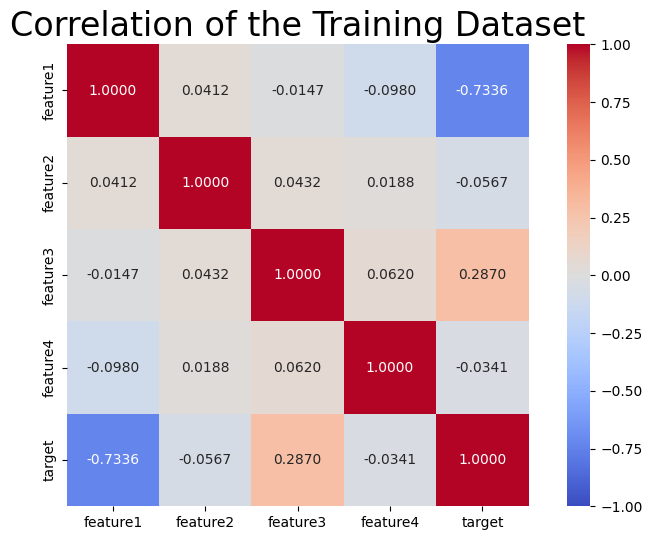

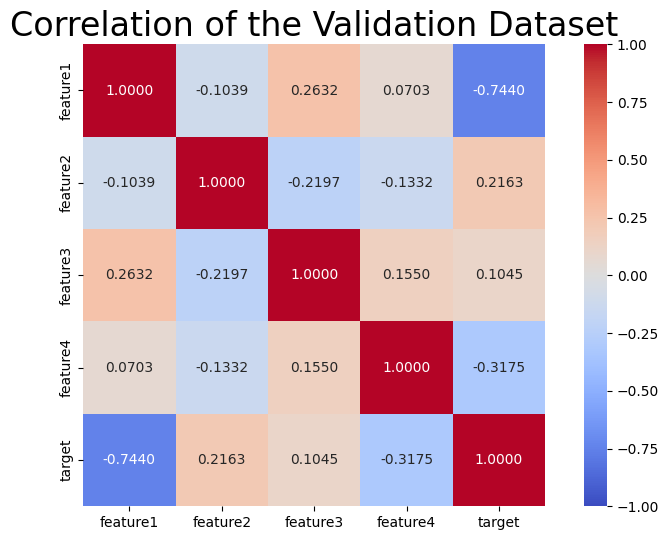

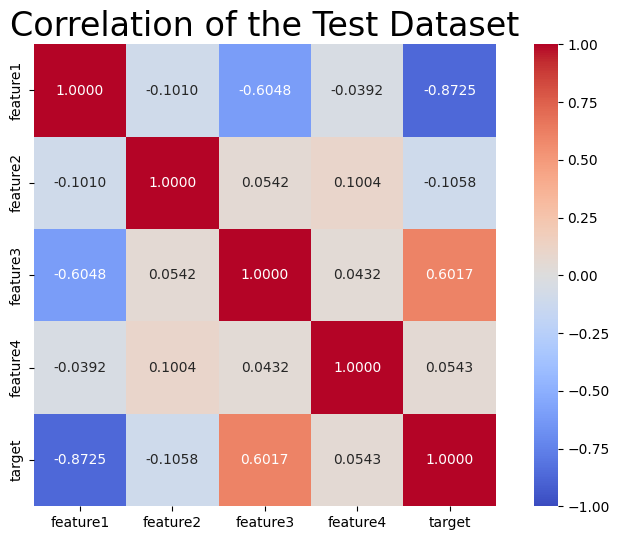

In [18]:
# Create and display the heatmap for the training, validation, and test dataset
create_heatmap(data_train,
               title = 'Correlation of the Training Dataset',
               filename = dataset_EDA_dir + 'corrplot_training_dataset.png')
create_heatmap(data_val, 
               title = 'Correlation of the Validation Dataset',
               filename = dataset_EDA_dir + 'corrplot_validation_dataset.png')
create_heatmap(data_test,
               title = 'Correlation of the Test Dataset',
               filename = dataset_EDA_dir + 'corrplot_test_dataset.png')

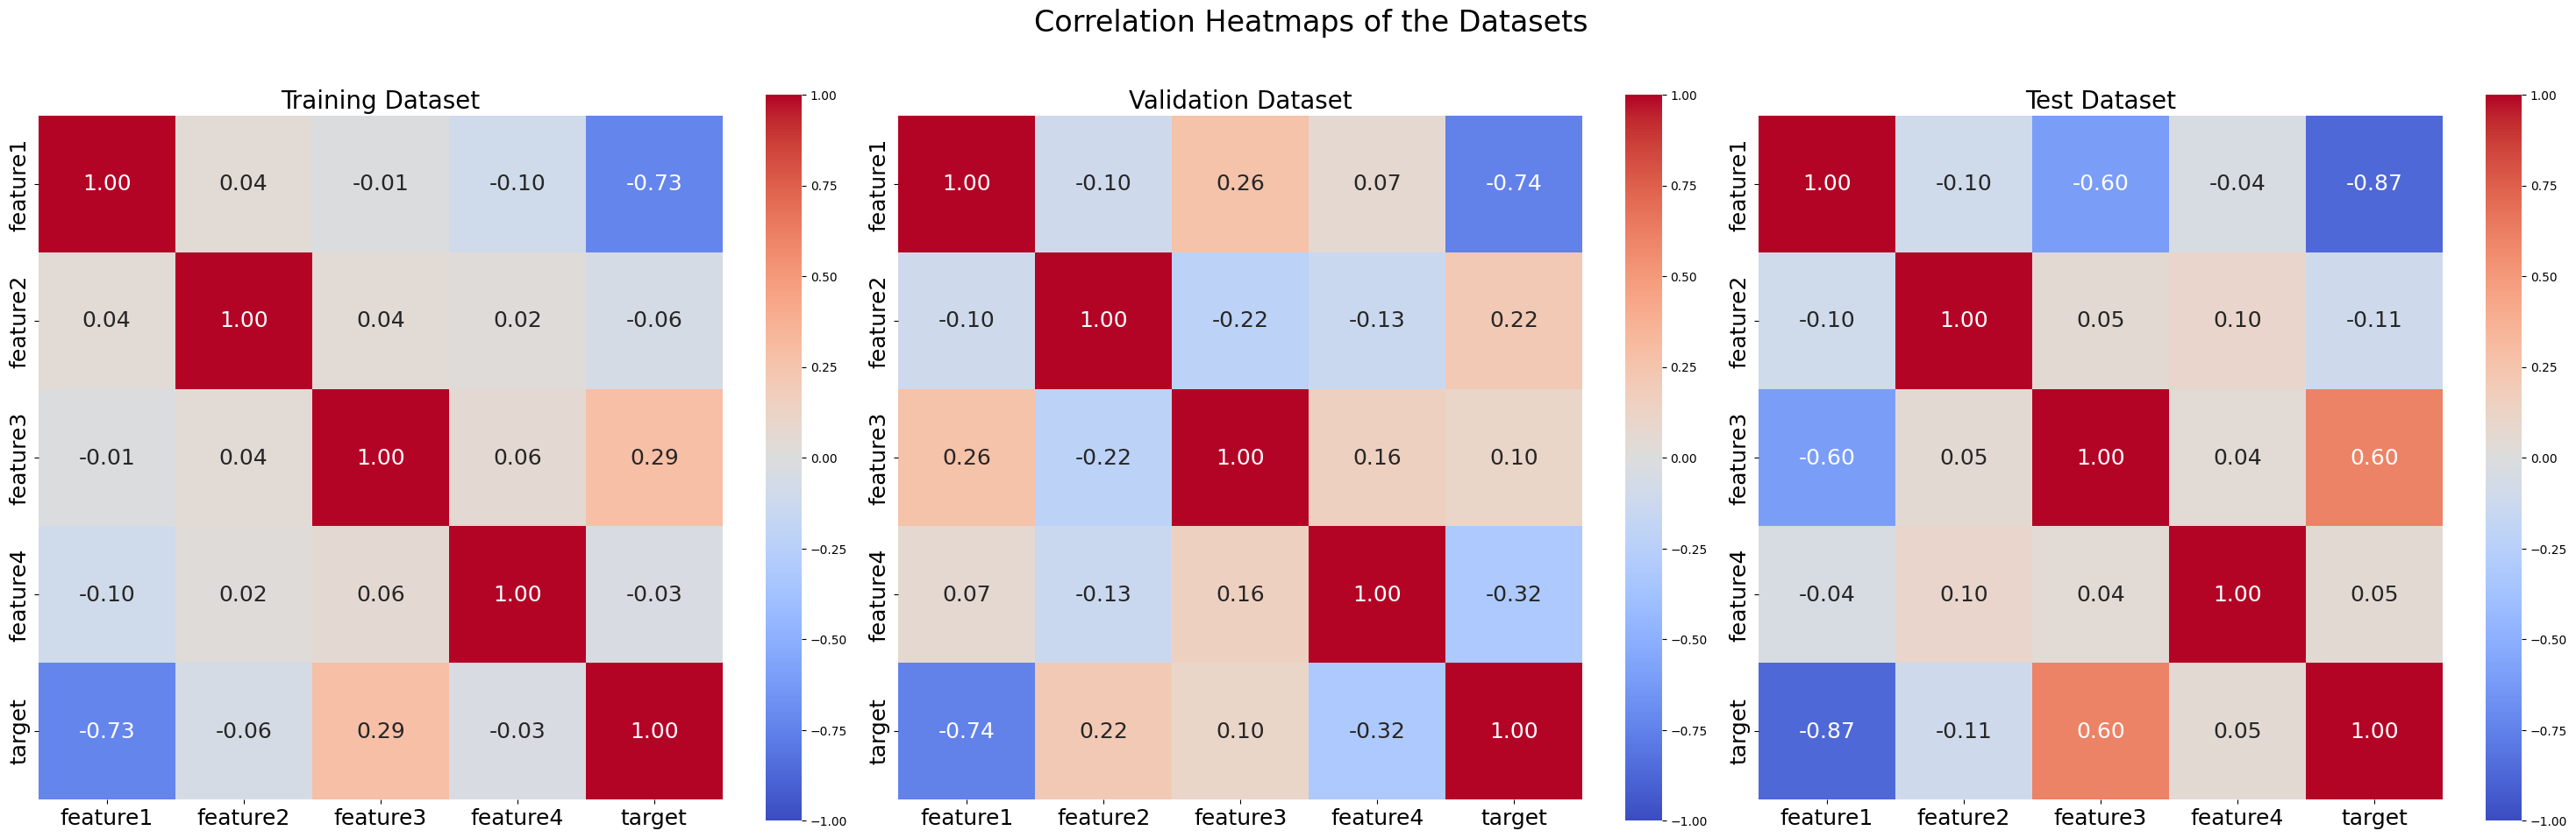

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the matplotlib figure
fig, axes = plt.subplots(1, 3, figsize=(30, 10))  # Adjust the figsize to fit your needs

# List of datasets and their titles
datasets = [(data_train, 'Training Dataset'),
            (data_val, 'Validation Dataset'),
            (data_test, 'Test Dataset')]

for ax, (dataset, title) in zip(axes.flat, datasets):
    # Calculate the correlation matrix and create the heatmap
    correlation_matrix = dataset.corr()
    sns.heatmap(correlation_matrix, ax=ax,
                vmin=-1, vmax=1, annot=True, annot_kws={"size": 18},
                cmap="coolwarm", fmt=".2f", square=True)
    ax.set_title(title, fontsize=20)
    ax.tick_params(axis='x', labelsize=18)
    ax.tick_params(axis='y', labelsize=18)

# Adjust layout for better visualization
plt.tight_layout()
plt.suptitle("Correlation Heatmaps of the Datasets", fontsize=24, y=0.98)  # Adjust 'y' for title spacing
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust the rect parameters as needed for the title and labels

# Save the entire figure with subplots
plt.savefig(dataset_EDA_dir + 'corrplot_combined_datasets.png')
plt.savefig(dataset_EDA_dir + 'corrplot_combined_datasets.pdf')
plt.show()


# Save / Load the dataset 

## Save the datasets into txt

In [20]:
# Store the column names in a list
column_names = data.columns.tolist()

In [21]:
def save_data(data, filename):
    data_array = data.to_numpy()
    np.savetxt(filename, data_array, delimiter='\t')

In [22]:
# Save each array to a text file without indices
save_data(data, dataset_dir + 'gen_data_reg.txt')
save_data(data_train, dataset_dir + 'data_train.txt')
save_data(data_val, dataset_dir + 'data_val.txt')
save_data(data_test, dataset_dir + 'data_test.txt')

## Load the datasets

In [23]:
## Load the generated dataset

data_train_load = np.loadtxt(dataset_dir + 'data_train.txt', delimiter='\t')
data_val_load = np.loadtxt(dataset_dir + 'data_val.txt', delimiter='\t')
data_test_load = np.loadtxt(dataset_dir + 'data_test.txt', delimiter='\t')

print('column_names:', column_names)

column_names: ['feature1', 'feature2', 'feature3', 'feature4', 'target']


In [24]:
# Create a new DataFrame with the column names
data_train_load = pd.DataFrame(data_train_load, columns=column_names)
data_val_load = pd.DataFrame(data_val_load, columns=column_names)
data_test_load = pd.DataFrame(data_test_load, columns=column_names)

In [25]:
data_train_load

,feature1,feature2,feature3,feature4,target
0,5.686272,5.917859,2.887154,1.234117,-0.386813
1,2.735838,2.596544,5.904369,2.664156,0.129050
2,0.639995,5.267234,0.370117,5.835571,0.446933
3,4.252998,4.093706,5.959320,5.755398,-0.521719
4,2.682438,0.044232,6.218021,3.781011,0.232000
...,...,...,...,...,...
95,3.339568,0.794196,4.267801,1.169116,0.125138
96,3.341722,4.928220,5.092593,4.147268,-0.034765
97,4.476627,2.561432,2.042849,0.770374,-0.892556
98,5.263746,3.528037,0.032255,2.872386,-0.850636


In [26]:
data_val_load

,feature1,feature2,feature3,feature4,target
0,0.226625,1.256248,4.564063,0.591240,0.472989
1,4.420742,1.459189,6.281134,6.058757,-0.574423
2,0.817451,1.526601,3.669322,1.038023,0.651362
3,1.061979,5.802537,0.522920,0.719917,0.612614
4,0.097455,1.969057,0.688729,5.201157,-0.089922
5,3.557408,0.287892,0.596078,2.057334,-0.459115
6,2.960212,0.221857,4.677627,4.138137,0.298501
7,4.454392,2.668790,4.533748,4.286586,-0.616739
8,5.952071,3.784413,5.150059,3.718645,-0.240822
9,5.824339,0.262709,6.212389,1.946049,-0.327291
